# Notebook — Fonctionnalités

Outils annexes de l'outil (dataset, regroup, sanity checks, exports, vidéo).
Les 3 phases de génération (generate / export / evaluate) sont dans
`notebook/generation.ipynb`.

## 1. Setup

**À exécuter en premier.** 

In [1]:
import sys
from pathlib import Path

def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "run_pipeline.py").exists():
            return p
    return start

ROOT = _find_root(Path.cwd())

_project = str(ROOT / "sources")
if _project not in sys.path:
    sys.path.insert(0, _project)

from notebook_tools import (
    RUNS_DIR,
    build_dataset, regroup_images,
    build_yolo_box, show_sanity,
    build_lard_box, show_sanity_lard,
    build_xplane_config, build_params_trace,
    build_video,
)
from runs import find_runs  # utilisé dans la cellule "Lister les runs"

print(f"ROOT     = {ROOT}")
print(f"RUNS_DIR = {RUNS_DIR}  (exists={RUNS_DIR.exists()})")

ROOT     = c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF
RUNS_DIR = C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs  (exists=True)


## 2. Lister les runs disponibles

Énumère tous les runs valides présents dans `runs/` (toutes générations
confondues), affichés en chemin relatif `<generation>/<run>`.

In [2]:
runs = find_runs(all_runs=True)
for r in runs:
    print(f"  - {r.relative_to(RUNS_DIR)}")
print(f"\n{len(runs)} run(s) trouve(s).")

  - generation_01\KRDU_5R

1 run(s) trouve(s).


## 3. Création du dataset (arborescence par piste / scénario)

Format aligné sur le CSV LARD natif.

```
dataset/
├── metadata.csv                         # toutes pistes, tous scénarios
└── <ICAO_RWY>/                          # ex: KPDX_10L
    ├── metadata.csv                     # tous scénarios de cette piste
    └── <ICAO_RWY>_<NNN>/                # ex: KPDX_10L_001
        ├── metadata.csv                 # ce scénario uniquement
        └── images/000000.jpg ...
```


In [3]:
build_dataset()

Dataset : C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset
  KRDU_5R                   <- footage  ( 483 imgs) [ok -> KRDU_5R/KRDU_5R_001]
Total : 483 images, 1 piste(s)
Metadata racine : C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset\metadata.csv (483 lignes)


{'KRDU_5R': ('footage', 483, 'ok -> KRDU_5R/KRDU_5R_001')}

In [4]:
# regroup_images() — regroupe + renumérote les images du dataset, avec metadata.csv.
#
# mode="piste" (defaut) : un dossier par piste
#     runs/dataset_regroup/<RWY>/img/000000.jpg ...
#     runs/dataset_regroup/<RWY>/metadata.csv      (scenarios de cette piste)
#
# mode="all"            : tout dans un seul dossier
#     runs/dataset_regroup/datasetr/img/000000.jpg ...
#     runs/dataset_regroup/datasetr/metadata.csv   (toutes pistes confondues)
#
# Les deux modes coexistent (chacun ne nettoie que son propre sous-dossier).

#regroup_images(mode="piste")
regroup_images(mode="all")

Regroupement global : C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset_regroup\datasetr
  KRDU_5R                    483 imgs
Total : 483 images, 1 piste(s)


## 4. Générer `yolo_box/` (images avec bbox YOLO dessinées)

Lance l'inférence YOLO sur les images sources (`degraded/` en priorité, sinon
`footage/`) et sauve les images annotées dans `runs/<gen>/<run>/yolo_box/`.

Usage :
- `build_yolo_box()`                          : toutes les runs
- `build_yolo_box("generation_01/KLAX_25R")`  

In [5]:
# build_yolo_box("generation_01/KLAX_25R")  # un seul run
build_yolo_box()

Results saved to C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\generation_01\KRDU_5R\yolo_box
  KRDU_5R -> yolo_box/


## 5. Sanity check : 3 images avec bbox YOLO 

Affiche première / milieu / dernière image d'UN run avec les bbox YOLO dessinées
(`degraded/` prio sinon `footage/`). Pas de mode "tous les runs" : sans argument,
prend le premier run trouvé.

Usage :
- `show_sanity()`                          : premier run trouvé
- `show_sanity("generation_01/KLAX_25R")`  : chemin composé si conflit

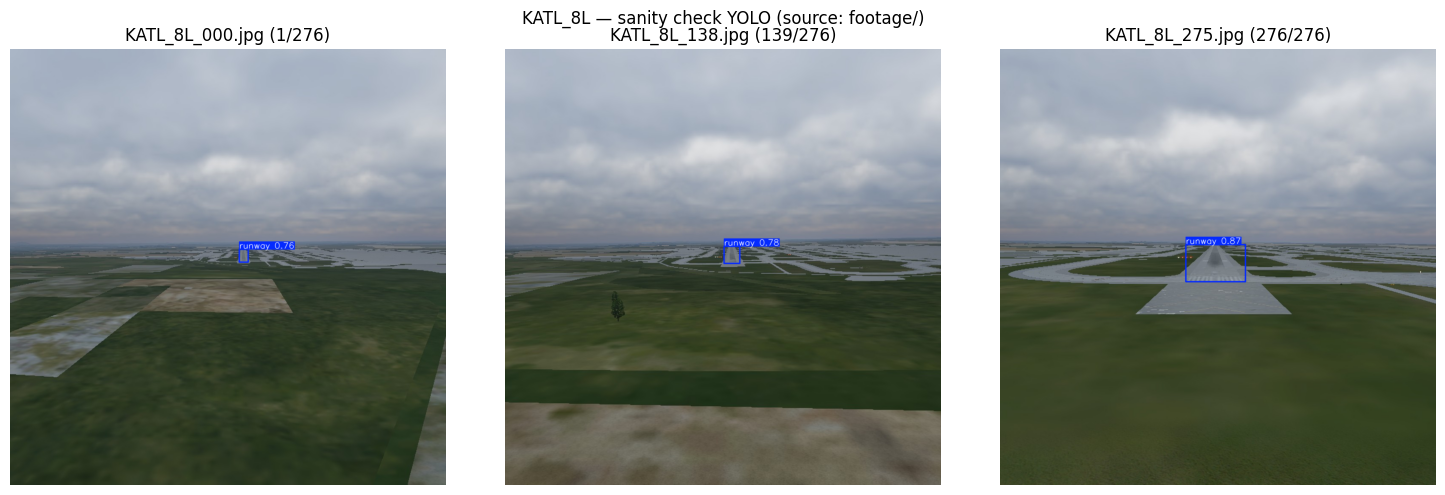

In [10]:
# show_sanity("generation_01/KLAX_25R")  # cible un run spécifique
show_sanity()

## 6. Générer `lard_box/` (images avec bbox GT LARD dessinées)

Usage :
- `build_lard_box()`                          : toutes les runs
- `build_lard_box("generation_01/KLAX_25R")`  : chemin composé si conflit

In [6]:
# build_lard_box("generation_01/KLAX_25R")  # un seul run (chemin composé)
build_lard_box()

  [GT-VIS] 483 images annotees dans lard_box/
  KRDU_5R -> lard_box/


## 7. Sanity check : 3 images avec bbox GT LARD 

Affiche première / milieu / dernière image d'UN run avec les 4 coins GT LARD
(`degraded/` prio sinon `footage/`). Pas de mode "tous les runs" : sans argument,
prend le premier run trouvé.

Usage :
- `show_sanity_lard()`                          : premier run trouvé
- `show_sanity_lard("KLAX_25R")`                : un run cible (si unique)
- `show_sanity_lard("generation_01/KLAX_25R")`  : chemin composé si conflit

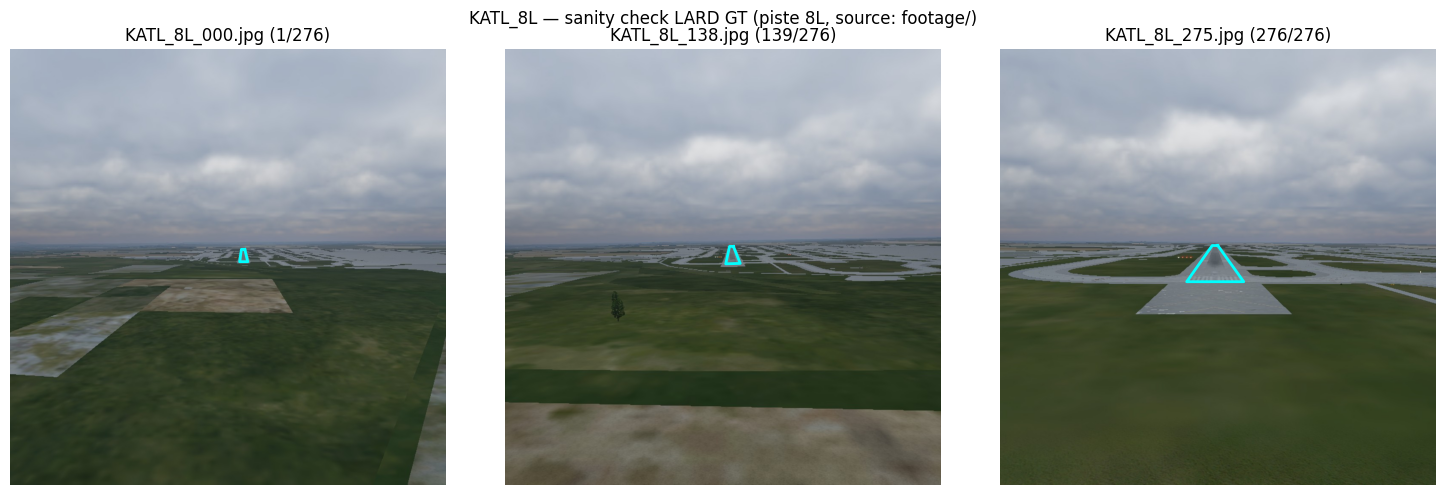

In [12]:
# show_sanity_lard("generation_01/KLAX_25R")  # cible un run spécifique
show_sanity_lard()

## 8. Générer `xplane_config.json`


**Contenu** : `width`/`height` (résolution), `fov_h`/`fov_v` (champ de vision),
`pilot_eye_x/y/z` (position œil pilote sur X-Plane12 dépendant de l'avion choisi), `weather_status` (ok/absent).

Usage :
- `build_xplane_config()`                          : toutes les runs
- `build_xplane_config("generation_01/KLAX_25R")`  : chemin composé si conflit

In [7]:
# build_xplane_config("generation_01/KLAX_25R")  # un seul run (chemin composé)
build_xplane_config()

  KRDU_5R -> xplane_config.json (1024x1024, weather=ok)


## 9. Générer `params_trace.xml`

**Contenu** : 
 `trajectory` (fps + paramètres de trajectoire), `weather` (paramètres météo), `faults`
(fautes capteur appliquées).

Usage :
- `build_params_trace()`                          : toutes les runs
- `build_params_trace("generation_01/KLAX_25R")`  : chemin composé si conflit

In [6]:
# build_params_trace("generation_01/KLAX_25R")  # un seul run (chemin composé)
build_params_trace()

  KORD_10L -> params_trace.xml
  KJAX_26 -> params_trace.xml


## 10. Générer une vidéo MP4 d'un run/des runs

Concatène les images du run (`degraded/` en priorité sinon `footage/`) en un MP4 (fps du yaml).

Usage :
- `build_video()`                          : toutes les runs
- `build_video(source="footage")`          : force la source (`footage` ou `degraded`)

In [8]:
# build_video("generation_02/LFPO_25", source="footage")  # run spécifique + source footage
build_video() 

  KRDU_5R -> KRDU_5R.mp4  (483 frames @ 12fps, footage/)
